# Lesson 02 — Makemore bigram language model

This notebook follows Karpathy's makemore lesson from the smallest useful language model: a **bigram** model.

The raw dataset lives at `data/raw/names.txt`. Each line is one name, and each name is treated as a sequence of characters.

The first goal is to learn counts like: given the current character, which next character usually follows? Later we will turn those counts into probabilities, sample new names, and compare this counting model with a tiny neural network.

Notebook path note: depending on how Jupyter starts the kernel, relative paths may be resolved from either the repository root or this notebook folder. The loading cell below handles both cases.


## 1. Load and inspect the names dataset

`words` will be a Python list of strings, where each string is one name such as `"emma"`.

The final line is a sanity check: it shows the first 10 names, the number of names, the shortest name length, and the longest name length. For the original makemore dataset, expect 32,033 names with lengths from 2 to 15 characters.


In [1]:
from pathlib import Path

candidate_paths = [
    Path("data/raw/names.txt"),          # kernel launched from repo root
    Path("../../../data/raw/names.txt"), # kernel launched from this notebook folder
]
names_path = next(path for path in candidate_paths if path.exists())
words = names_path.read_text(encoding="utf-8").splitlines()

words[:10], len(words), min(len(w) for w in words), max(len(w) for w in words)


(['emma',
  'olivia',
  'ava',
  'isabella',
  'sophia',
  'charlotte',
  'mia',
  'amelia',
  'harper',
  'evelyn'],
 32033,
 2,
 15)

## 2. Count bigrams

A **bigram** is a pair of neighboring tokens. Here the tokens are characters, plus two special boundary tokens: `<S>` for the start of a name and `<E>` for the end of a name.

The dictionary `b` maps each pair `(previous_token, next_token)` to the number of times that pair appears in the dataset. For example, `('e', 'm')` counts how often `m` follows `e`.

These counts are the raw material for the first model: later, each row of counts becomes a probability distribution over the next character.


In [2]:
b = {}
for w in words:
    chs = ["<S>"] + list(w) + ["<E>"]
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


## 3. Inspect the most common bigrams

Sorting `b.items()` by the count shows which character pairs appear most often in the dataset.

The sorting key `lambda kv: kv[1]` means: for each `(bigram, count)` pair, sort by the count, not by the characters. `reverse=True` puts the largest counts first.

This is a quick way to check whether the counts make sense before moving them into a tensor.


In [3]:
sorted(b.items(), key=lambda kv: kv[1], reverse=True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

## 4. Prepare a tensor count table

The dictionary `b` is easy to inspect, but a model will be easier to build from a rectangular table of numbers.

`N` is a 28 × 28 PyTorch tensor: 26 letters plus two boundary tokens. Rows represent the previous token, columns represent the next token, and each entry will hold a count.

`dtype=torch.int32` says these entries are integer counts, not decimal probabilities yet.


In [4]:
import torch

N = torch.zeros((28, 28), dtype=torch.int32)

## 5. Build character lookup tables

Tensors are indexed with integers, so we need to translate characters like `"a"` or `"m"` into numeric positions.

`stoi` means "string to integer": it maps each character or boundary token to an index. `itos` means "integer to string": it maps indices back to display labels.

Boundary-token note: this cell adds `<S>` and `<E>` to `stoi` so they can be counted in `N`. If you later use `itos` to label all 28 rows and columns, make sure the boundary-token labels are available there too.


In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(chars)}
stoi["<S>"] = 26
stoi["<E>"] = 27
itos = {i: s for i, s in enumerate(chars)}

## 6. Fill the tensor with bigram counts

This loop repeats the same counting idea as the dictionary version, but writes the result into `N`.

For each bigram `(ch1, ch2)`, `ix1` is the row index for the previous token and `ix2` is the column index for the next token. `N[ix1, ix2] += 1` increments that cell.

After this cell, `N[row, column]` answers: how often did this next token follow this previous token in the names dataset?


In [7]:
for w in words:
    chs = ["<S>"] + list(w) + ["<E>"]
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

tensor([[ 1112,  1082,   940,  2084,  1384,   268,   336,  4664,  3300,   350,
          1136,  5056,  3268, 10876,   126,   164,   120,  6528,  2236,  1374,
           762,  1668,   322,   364,  4100,   870,     0, 13280],
        [  642,    76,     2,   130,  1310,     0,     0,    82,   434,     2,
             0,   206,     0,     8,   210,     0,     0,  1684,    16,     4,
            90,     0,     0,     0,   166,     0,     0,   228],
        [ 1630,     0,    84,     2,  1102,     0,     4,  1328,   542,     6,
           632,   232,     0,     0,   760,     2,    22,   152,    10,    70,
            70,     0,     0,     6,   208,     8,     0,   194],
        [ 2606,     2,     6,   298,  2566,    10,    50,   236,  1348,    18,
             6,   120,    60,    62,   756,     0,     2,   848,    58,     8,
           184,    34,    46,     0,   634,     2,     0,  1032],
        [ 1358,   242,   306,   768,  2542,   164,   250,   304,  1636,   110,
           356,  6496,  1

## 7. Visualize the count table

`plt.imshow(N)` draws the count tensor as an image: brighter or darker cells correspond to larger or smaller counts.

This helps you see structure that is hard to spot in a long list of numbers, such as common endings or common letters after `a`.

The color bar is a scale: it connects the image color back to the underlying count value.


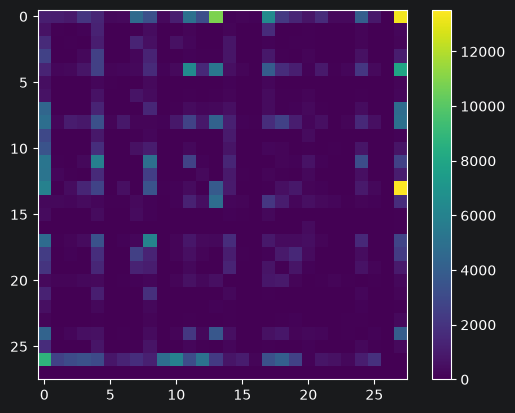

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(N)
plt.colorbar()